In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import itertools
%pip install plotly
import plotly.graph_objects as go

## Audio Feature Analysis


In [4]:
## data cleaning and merging datasets
hot_100 = pd.read_csv("Hot Stuff.csv")
audio_features = pd.read_csv("Hot 100 Audio Features.csv")

hot_100_condensed = (
    hot_100.sort_values("Weeks on Chart", ascending=False).drop_duplicates(subset="SongID")
)

hot_100_condensed = hot_100_condensed.drop(columns=["url"])

data = pd.merge(hot_100_condensed, audio_features, on="SongID", how="inner")

cols = ["spotify_track_id", "spotify_track_preview_url", "time_signature"]
data = data.drop(columns=cols)

data = data.dropna()

data.to_csv("hot_100_dataset.csv", index = False)

In [5]:
## add a column that represents a class based on peak position and a column for encoded class
data = pd.read_csv("hot_100_dataset.csv")

def classify_popularity(peak):
    if peak <= 10:
        return 'SmashHit'
    elif peak <= 30:
        return 'Hit'
    elif peak <= 60:
        return 'Popular'
    else:
        return 'OK'

data["class"] = data["Peak Position"].apply(classify_popularity)
le = LabelEncoder()
data['encoded_class'] = le.fit_transform(data['class'])

In [6]:
features = ['danceability', 'energy', 'loudness', 'valence', 'tempo', 'acousticness']
X = data[features]
y = data['encoded_class']
scaler = StandardScaler()

In [7]:
## determine and visualize which audio features are most important to chart popularity

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='teal')
plt.title("Features Most Important to Chart Popularity Prediction")
plt.xlabel("Importance")
plt.xlim(0.06,0.2)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

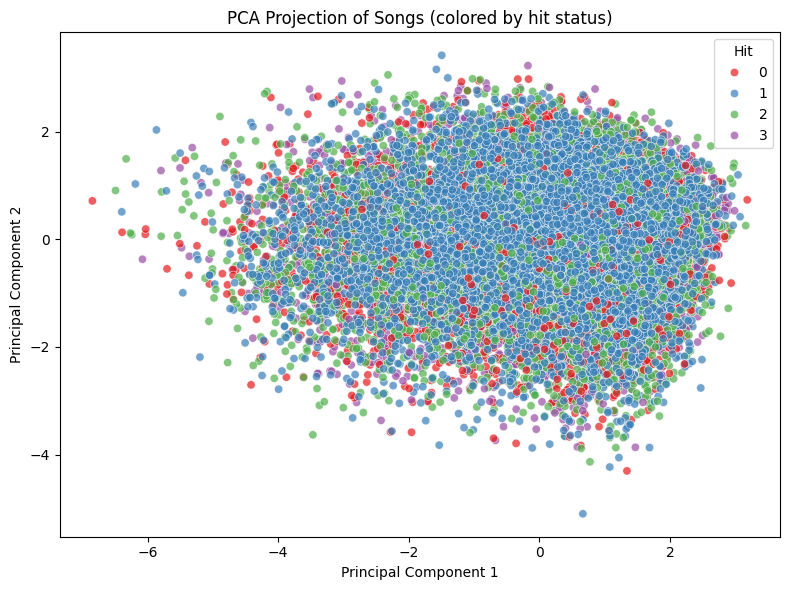

In [9]:
## principal component analysis on features
pca = PCA(n_components=2)
X_scaled = StandardScaler().fit_transform(X)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=data['encoded_class'], palette='Set1', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title("PCA Projection of Songs (colored by hit status)")
plt.legend(title='Hit')
plt.tight_layout()
plt.show()

In [12]:
## predict weeks on Hot 100 chart based on audio features

y = data['Weeks on Chart']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


RMSE: 58.99
R² Score: 0.07


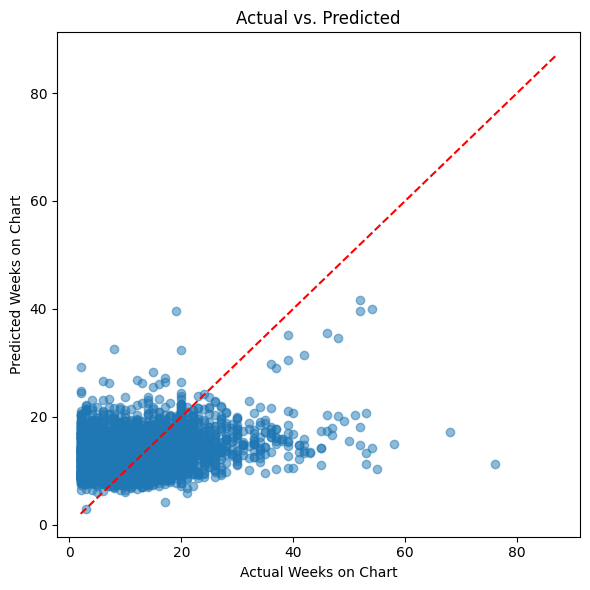

In [13]:
## visualization of random forest prediction
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Weeks on Chart")
plt.ylabel("Predicted Weeks on Chart")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()

## Genre Analysis

In [8]:
# feature engineering for major genre categories
genres = ['pop', 'rock', 'hip hop', 'rap', 'country', 'soul', 'funk', 'r&b', 'metal']
data['spotify_genre'] = data['spotify_genre'].str.lower()
for genre in genres:
    data[genre] = data['spotify_genre'].apply(lambda x: 1 if genre in x else 0)

print(data.head())
data.to_csv('hot_100_dataset_augmented', index=False)


       WeekID  Week Position           Song_x      Performer_x  \
0   5/10/2014             49      Radioactive  Imagine Dragons   
1   3/22/2014             45             Sail       AWOLNATION   
2   5/29/2021             23  Blinding Lights       The Weeknd   
3  10/10/2009             48        I'm Yours       Jason Mraz   
4  10/10/1998             45    How Do I Live      LeAnn Rimes   

                       SongID  Instance  Previous Week Position  \
0  RadioactiveImagine Dragons         2                    48.0   
1              SailAWOLNATION         2                    41.0   
2   Blinding LightsThe Weeknd         2                    12.0   
3         I'm YoursJason Mraz         1                    49.0   
4    How Do I LiveLeAnn Rimes         1                    48.0   

   Peak Position  Weeks on Chart      Performer_y  ... encoded_class pop  \
0              3              87  Imagine Dragons  ...             3   0   
1             17              79       AWOLNATIO

<Axes: title={'center': 'Share of Songs per Genre Over Time'}, xlabel='year'>

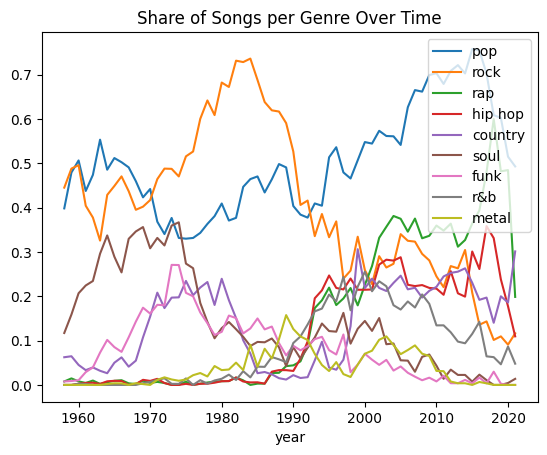

In [10]:
#plot genre trends over time

data['year'] = pd.to_datetime(data['WeekID']).dt.year
genre_trends = data.groupby('year')[['pop', 'rock', 'rap','hip hop', 'country', 'soul', 'funk', 'r&b', 'metal']].mean()

genre_trends.plot(title="Share of Songs per Genre Over Time")

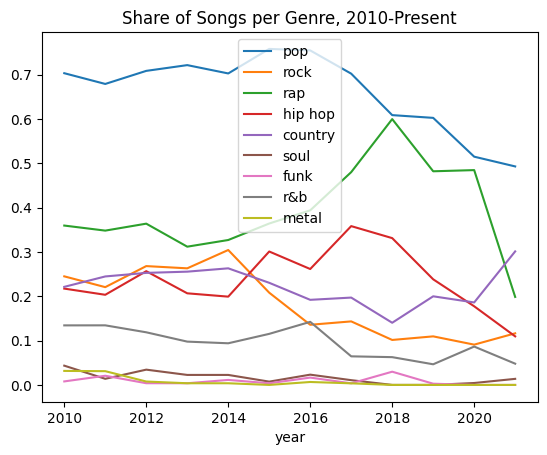

In [11]:
# plot more recent genre trends
df_recent = data[data['year'] >= 2010]
genre_trends_recent = df_recent.groupby('year')[['pop', 'rock', 'rap','hip hop', 'country', 'soul', 'funk', 'r&b', 'metal']].mean()

genre_trends_recent.plot(title="Share of Songs per Genre, 2010-Present")
genre_trends_recent.to_csv('hot_100_augmented_recent', index=False)

In [25]:
# model recent chart popularity based on genre and weeks on chart

def label_popularity(weeks):
    if weeks >= 20:
        return 'SmashHit'
    elif weeks >= 10:
        return 'Hit'
    elif weeks >= 5:
        return 'Popular'
    else:
        return 'Okay'

df_recent['popularity_class'] = df_recent['Weeks on Chart'].apply(label_popularity)

X = df_recent[['pop', 'rock', 'rap','hip hop', 'country', 'soul', 'funk', 'r&b', 'metal']]
y = df_recent['popularity_class']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
print(classification_report(y_test, clf.predict(X_test)))

<ipython-input-25-f6885916a2d8>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_recent['popularity_class'] = df_recent['Weeks on Chart'].apply(label_popularity)


              precision    recall  f1-score   support

         Hit       0.34      0.14      0.20       210
        Okay       0.35      0.24      0.28       154
     Popular       0.00      0.00      0.00        96
    SmashHit       0.45      0.79      0.58       356

    accuracy                           0.43       816
   macro avg       0.29      0.29      0.27       816
weighted avg       0.35      0.43      0.36       816



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


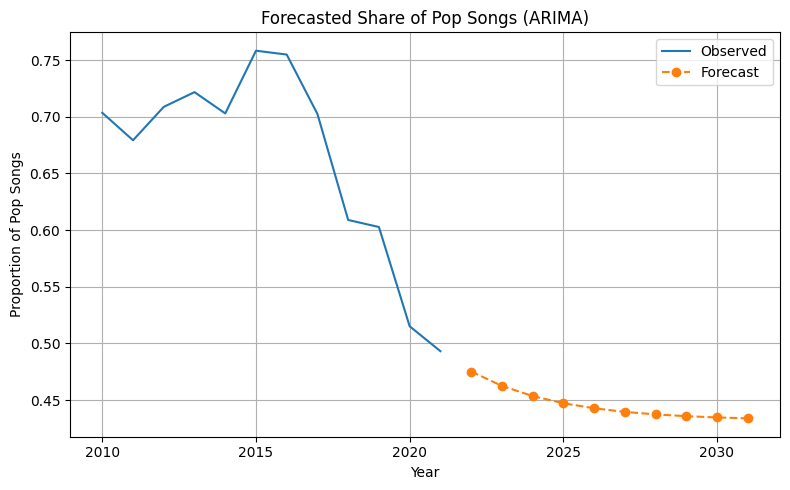

In [17]:
# time series forecasting to predict future genre trends w/ most popular genres as seen in earlier plot

pop_trend = df_recent.groupby('year')['pop'].mean()

pop_model = ARIMA(pop_trend, order=(1, 1, 1))
pop_fit = pop_model.fit()
pop_forecast = pop_fit.forecast(steps=10)



future_years = range(pop_trend.index.max() + 1, pop_trend.index.max() + 11)

plt.figure(figsize=(8, 5))
plt.plot(pop_trend.index, pop_trend.values, label="Observed")
plt.plot(future_years, pop_forecast, label="Forecast", linestyle="--", marker="o")
plt.title("Forecasted Share of Pop Songs (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Proportion of Pop Songs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


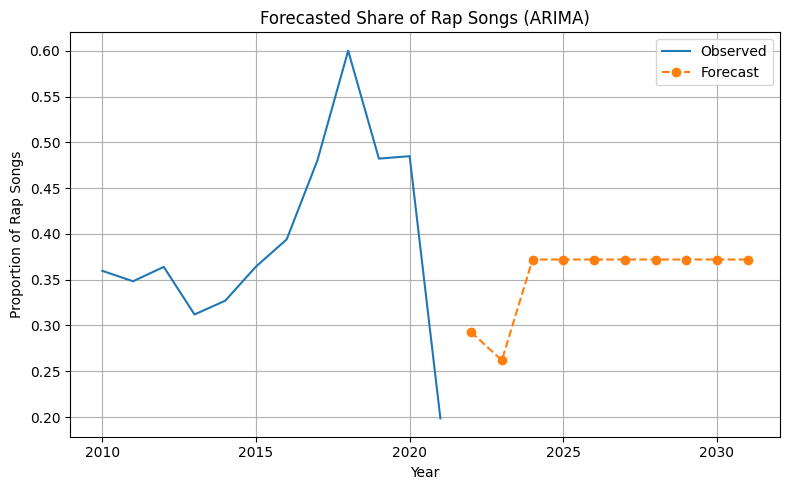

In [16]:
rap_trend = df_recent.groupby('year')['rap'].mean()

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

warnings.filterwarnings("ignore")

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(rap_trend, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

rap_forecast = best_model.forecast(steps=10)

plt.figure(figsize=(8, 5))
plt.plot(rap_trend.index, rap_trend.values, label="Observed")
plt.plot(future_years, rap_forecast, label="Forecast", linestyle="--", marker="o")
plt.title("Forecasted Share of Rap Songs (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Proportion of Rap Songs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

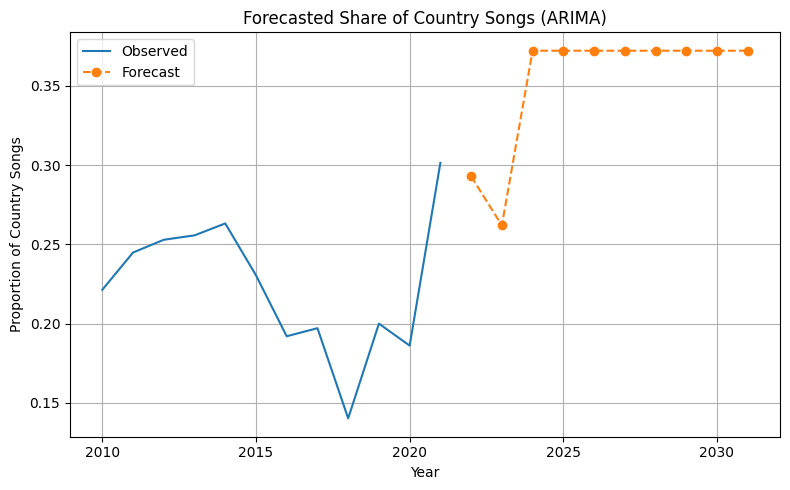

In [18]:
country_trend = df_recent.groupby('year')['country'].mean()

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

warnings.filterwarnings("ignore")

p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_aic = np.inf
best_order = None
best_model = None

for order in pdq:
    try:
        model = ARIMA(rap_trend, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
    except:
        continue

country_forecast = best_model.forecast(steps=10)

plt.figure(figsize=(8, 5))
plt.plot(country_trend.index, country_trend.values, label="Observed")
plt.plot(future_years, country_forecast, label="Forecast", linestyle="--", marker="o")
plt.title("Forecasted Share of Country Songs (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Proportion of Country Songs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
## forecast all genres with ARIMA and exponential smoothing and visualize with plotly
forecast_years = list(range(2024, 2031))
genre_forecasts = {}

for genre in genres:
    yearly_share = df_recent.groupby('year')[genre].mean()

    model = ARIMA(yearly_share, order=(1, 1, 1))
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=len(forecast_years))

    full_series = pd.concat([yearly_share, pd.Series(forecast.values, index=forecast_years)])
    genre_forecasts[genre] = full_series

fig = go.Figure()


for genre, series in genre_forecasts.items():
    label = genre.replace("is_", "").replace("_", " ").title()
    fig.add_trace(go.Scatter(
        x=series.index,
        y=series.values,
        mode='lines+markers',
        name=label
    ))

fig.update_layout(
    title='Genre Prevalence Forecast (2010–2030)',
    xaxis_title='Year',
    yaxis_title='Share of Songs on Chart',
    hovermode='x unified',
    template='plotly_white',
    legend_title='Genre',
    width=900,
    height=500
)


fig.show()
fig.write_html("genre_forecast_plot.html")